In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression   # Model eğitme için
from sklearn.decomposition import PCA  #Model görselleştirme için
from sklearn.metrics import accuracy_score  # Sapmayı hesaplamak için
from sklearn.metrics import confusion_matrix    #İlk metriksim confusion metriksi için
from sklearn.metrics import roc_curve, roc_auc_score  #ROC grafiği için gerekli 
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score



%matplotlib inline

In [80]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#Veriyi bilgisayarımdaki path'den bulup okudu

In [81]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [82]:
df.shape


(7043, 21)

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [84]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()


np.int64(11)

In [85]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

#Burda errors="coerce" kullanmak dönüşütürmede sorun yaşarsa NaN yapmasını sağlıyor.

In [86]:
df['Churn'].value_counts(normalize=True)  # yüzde olarak
df['Churn'].value_counts()

#Burdan baktığımda unbalanced bir veriye sahipim gibi duruyor.Bunun kararını modeli oluşturup metrikleri inceledikten sonra karar vericem.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [87]:
for col in df.select_dtypes(include='str').columns:
    print(df[col].unique())


#Burası sayesinde encode edeceğim kolonların içeriklerine for döngüsü ve unique fonkisyonu ile hem hatasız hem de hızlıca oluşıcam


<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
<StringArray>
['No', 'Yes', 'No internet

#Değişkenlerimi birleştirelim


In [88]:

cols_to_fix =[ 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:

          df[col]= df[col].replace("No internet service","No")
df['MultipleLines']= df['MultipleLines'].replace("No phone service","No")


In [89]:
for col in df.select_dtypes(include='str').columns:
    print(df[col].unique())



<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Month-to-month', 'One year', 'Two ye

Encode edelim

In [90]:
liste=[ 'MultipleLines','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in liste:
    df[col] = df[col].replace({"No": 0, "Yes": 1})

Kontrol edelim


In [91]:
liste=[ 'MultipleLines','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','Partner','Dependents','PhoneService','PaperlessBilling','Churn']


for i in liste:
    print(df[i].unique())

df['gender'] = df['gender'].replace({"Female": 0, "Male": 1})


[0 1]
[0 1]
[1 0]
[0 1]
[0 1]
[0 1]
[0 1]
[1 0]
[0 1]
[0 1]
[1 0]
[0 1]


Aynı encode işlemlerini yapmaya devam edelim.


In [92]:
print(df['gender'].unique())
#Ne olur ne olmaz elle konrtol

[0 1]


Bu sayede bütün binary kolonlar encode edilmiş oldu.


In [93]:
for col in df.select_dtypes(include='str').columns:
    print(df[col].unique())



<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


In [94]:
cols_to_encode_nominal = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=cols_to_encode_nominal)

Sıra Nominal verileri encode etmekte


In [95]:

liste = ['InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No',
         'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
         'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)',
         'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
for col in liste:
    df[col] = df[col].replace({False: 0, True: 1})


#Aslında model burdaki true ve false ları zaten 0 ve 1 olarak görecek ama ben yine de yapmak istedim

In [96]:
cols_to_convert = df.select_dtypes(include=['bool', 'object']).columns.tolist()
cols_to_convert.remove('customerID')
df = df.drop('customerID', axis=1)

for col in cols_to_convert:
    df[col] = df[col].astype(int)

#Kendimce sayıya dönüştürmüş olabiliirm ama hala pythona bu sayı demem gerekli bu nedenle encode ettiğim tüm kolonlara veri tipi değişimi uyguladım.
#Ayno zamanda modeli eğitirken kullanmayacağımız customerID kolonunu da attım df den.
#

/var/folders/bh/c7386y_56js2n2360hrm_rq80000gn/T/ipykernel_2293/4094693345.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_to_convert = df.select_dtypes(include=['bool', 'object']).columns.tolist()


In [97]:

df.info()



<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 non-null   in

In [98]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].isnull().sum())
#TotalCharges içinde yer alan NaN gözlemleri de 0 a atadım ki 11 tanecik de olsa gözlem kaybetmeyelim.
#Kontrolü de NaN değerlere 0 atadığım için bunların toplammı 0 olmalıdır idyerek kontrol ettim.


0


MODELİ OLUŞTURALIM


In [99]:
X = df.drop('Churn', axis=1)#x değişkenlerini belirleyelim bunlar churn hariç büyün veri kolonları olacak,y değişkeni target yani churn kolonu olacak.
y = df['Churn']
print(X.shape)
print(y.shape)

(7043, 26)
(7043,)


In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=61)

MODELİ OLUŞTURMA


In [101]:
model = LogisticRegression(max_iter=10000)#Brda sklearn'den gelen class yapısını çağırıyorum.-->12 Eylül gününden merhabalar.max_iteri bu şekilde yapmak sorunu çözmüyor.Bunun yerine featur scaling yapmalıyız.
model.fit(X_train, y_train)# Geri kalan her şeyi class hallediyor.

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

Daha iyi gradient decent parametreleri için iterationsu 100 kat arttırdım.Bu hem indirgenmiş olanlara etki etmedi hem de doğru indirgenmemiş olanları daha iyi indirgedi

In [102]:
model.coef_
#Burası ile x değişkenlerine modelin hangi w ağrılıklarını verdiğini görüyoruz

array([[-2.48326911e-02,  1.71668523e-01, -3.20830216e-02,
        -1.23753557e-01, -5.75758667e-02, -7.55069349e-01,
         2.15233852e-01, -3.92086569e-01, -2.45225221e-01,
        -7.04008009e-02, -4.61436800e-01,  8.98470350e-02,
         1.27353954e-01,  3.21672259e-01,  7.42706506e-03,
         3.15921729e-04, -1.18107343e-01,  4.52395568e-01,
        -7.18012035e-01,  6.08955796e-01, -9.52759358e-02,
        -8.97403670e-01, -1.48017409e-01, -1.93081997e-01,
         1.76799269e-01, -2.19423673e-01]])

In [103]:
model.intercept_
#BU da başlangıç eğimim yani b sabitim normalde bu adımlar iiçin iki farklı fonksiyon ve döngüler uygulamam gerekecekti.


array([-0.40590588])

Veriyi ve modeli her ne kadar 26 değişkenden oluşuyor olsa da aşağı yukarı ne kadar etki ettiklerini bar chart ve diğer görselleştirme ile modelin kendisini göstermeye çalıştım

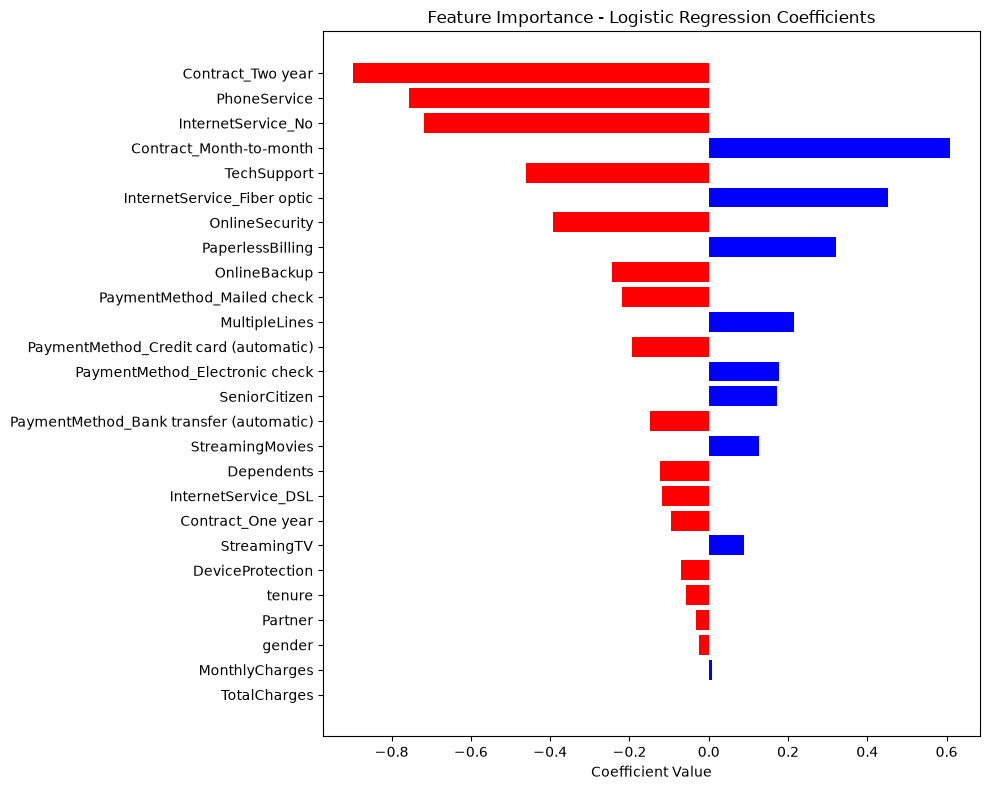

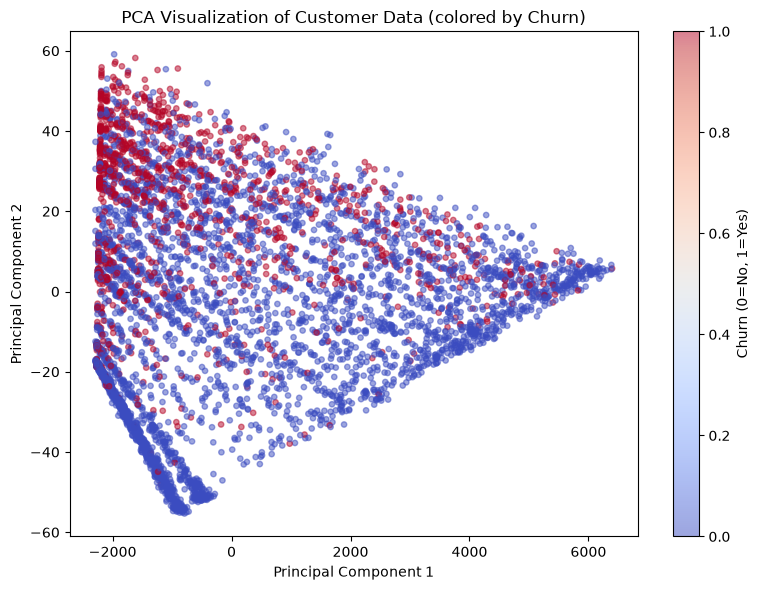

In [104]:
# 1. Feature Importance
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['red' if c < 0 else 'blue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

# 2. PCA ile 2 Boyutlu Görselleştirme
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                       c=y_train, cmap='coolwarm', alpha=0.5, s=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Customer Data (colored by Churn)')
plt.colorbar(scatter, label='Churn (0=No, 1=Yes)')
plt.tight_layout()
plt.show()


#Bu kısımda claude kodu yazdı

Bu sayede modelimi oluşturmuş oldum.


LogisticRegression() içinde kullanılan bütün fonksioynların kodlanmış halleri geliştirme günlüğündedir.Github README kısmında linke tıklayarak ulaşabilirsiniz.


MODELİ TEST EDELİM

In [105]:
y_pred=model.predict(X_test)

# Şuanda y_pred değişkeninde bütün veri setinin yüzde yirmisi için oluşturulmuş tahmin sonuçları var bu bir diz oluyor aslında.


In [106]:
accuracy = accuracy_score(y_test, y_pred)   # Normalde for döngüsü ile tek tek karşılaştırmam gerekecekti sağolsun sklearn var direkt gömülü fonksiyonu yazmışlar.

print(accuracy)

0.8133427963094393


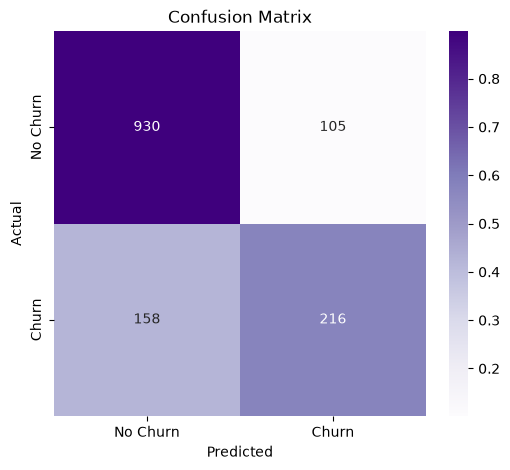

In [107]:


cm = confusion_matrix(y_test, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#Güzel görselleştirme için claude a süslettirdim.

True Negative (TN) = 3714 — Gerçekte "No Churn" olup, modelin de "No Churn" dediği


True Positive (TP) = 797 — Gerçekte "Churn" olup, modelin de "Churn" dediği


False Negative (FN) = 698 — Gerçekte "Churn" olup, modelin "No Churn" dediği (kaçırdığı riskli müşteriler)


False Positive (FP) = 426 — Gerçekte "No Churn" olup, modelin "Churn" dediği (yanlış alarm)

İhtiyacım olanlarlar TP ,FP ve FN 


In [108]:
TN, FP, FN, TP = cm.ravel() #Recall ve precision hesabı için burdaki değerleri çekmem gerekli.


In [109]:
#Precision:
precision=(TP)/(TP+FP)

#Recall:
recall=(TP)/(TP+FN)

print(precision,recall)

0.6728971962616822 0.5775401069518716


In [110]:
f1=2/((1/precision)+(1/recall))

print(f1)

0.6215827338129496


ROC ve AUC


In [111]:
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

In [112]:

target_recall = 0.75
idx = np.argmax(tpr >= target_recall)
best_threshold = thresholds[idx]
print(f"Seçilen eşik: {best_threshold}, bu eşikteki TPR: {tpr[idx]}, FPR: {fpr[idx]}")

Seçilen eşik: 0.32643267383482155, bu eşikteki TPR: 0.7513368983957219, FPR: 0.21835748792270532


Bu noktada belirlediğim %75 ayrılacakları doğru tahmin etme durumu için gerekli olan eşik değer 0.32245994187981913 olarak bulundu şimdi bu eşik değeri kullanrak modele bir daha tahminleme yaptıracağım

In [113]:
y_pred_new = (model.predict_proba(X_test)[:, 1] > best_threshold).astype(int)

In [114]:

cm_new = confusion_matrix(y_test, y_pred_new)
precision_new = precision_score(y_test, y_pred_new)
recall_new = recall_score(y_test, y_pred_new)
f1_new = f1_score(y_test, y_pred_new)

print("Eski (0.5 eşik):", "Precision:", precision, "Recall:", recall, "F1:", f1)
print("Yeni (0.322 eşik):", "Precision:", precision_new, "Recall:", recall_new, "F1:", f1_new)

Eski (0.5 eşik): Precision: 0.6728971962616822 Recall: 0.5775401069518716 F1: 0.6215827338129496
Yeni (0.322 eşik): Precision: 0.5533596837944664 Recall: 0.7486631016042781 F1: 0.6363636363636364


Ama en iyiyi tek tek elle bakmak yerine şöyle yapmamız daha doğru olur:


In [115]:

f1_scores = []
for t in thresholds:
    y_pred_t = (model.predict_proba(X_test)[:, 1] >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]
print(f"F1'i maksimize eden eşik: {best_threshold_f1}, F1: {f1_scores[best_idx]}")

F1'i maksimize eden eşik: 0.27744438817869965, F1: 0.6423982869379015


Görüldüğü üzere en ideal eşik benim bulduğuma çok yakın bir eşik çıktı bu nedenle bu eşik olarak bıırakacağım.

Her eşik değer için hesağlana ve ideal sigmoid fonksiyon eşik değerini kısmızı nokta ile belirten ROC grafiği:

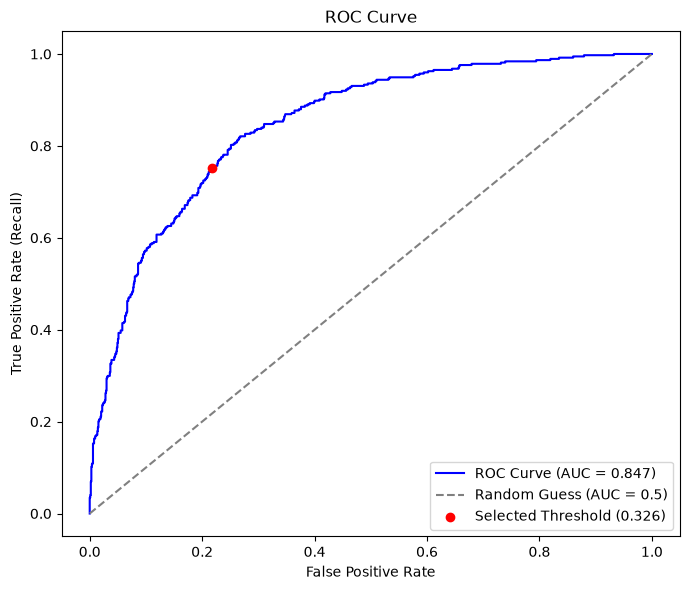

AUC Score: 0.847


In [116]:

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')

# Seçilen eşik noktasını işaretle
idx = np.argmax(tpr >= 0.75)
plt.scatter(fpr[idx], tpr[idx], color='red', zorder=5, 
            label=f'Selected Threshold ({thresholds[idx]:.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.3f}")

Ve görüldüğü üzere AUC alanı başarıı bir şekilde 0.84.Kiii gayet yüksek bir değer:)

In [117]:
import joblib

joblib.dump(model, '../models/model.pkl')

#Modelin burdaki jupyterden ayrı duracağı bir dosya ekledim.

['../models/model.pkl']

# Şİmdi modeli deploy edelim: